In this notebook, I will test 2 cluster algorithm

- [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN)
- [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation)


In [32]:
import json
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib import cm

from sklearn.cluster import DBSCAN
from shapely.geometry import MultiPoint
from shapely.ops import unary_union

## generate synthetick data

In [33]:
json_path = r"/home/thang_sinay/unlocode/output/shipnext_ports_test.json"

with open(json_path, 'r') as file:
    shipnext_data = json.load(file)

In [34]:
center = shipnext_data[-1]['coordinates'][::-1]
cx, cy = center
cx,cy

(56.1666, 10.2333)

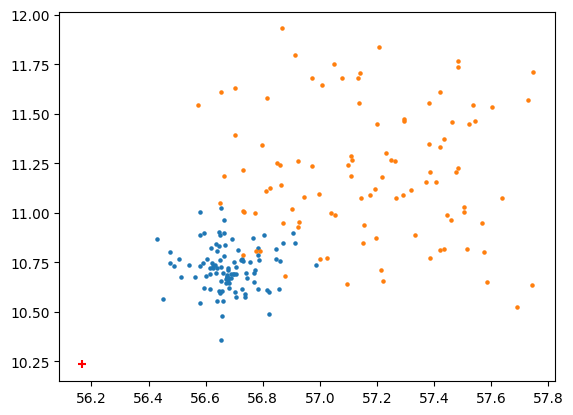

In [35]:
points = []

cluster = np.random.randn(100, 2)*0.1 + np.array([cx+0.5, cy+0.5])
points.append(cluster)
points = np.vstack(points)

noise = np.random.rand(100, 2) * 1
data = np.vstack(points + [noise])

plt.scatter(cx,cy, marker = "+", c='r')
plt.scatter(points[:, 0], points[:,1], s=5)
plt.scatter(data[:, 0], data[:,1], s=5)
plt.show()

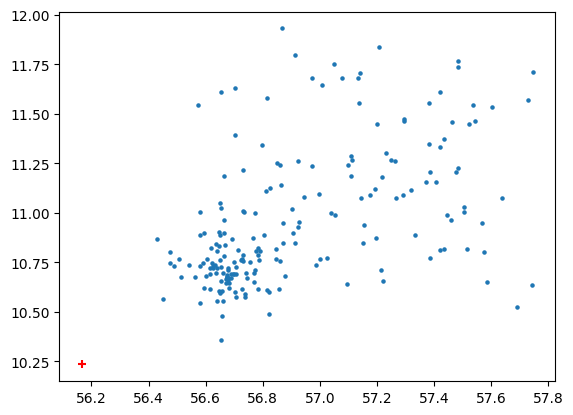

In [36]:
new_data = np.concatenate((points, data))

lat, lon = new_data[:,0], new_data[:,1]

plt.scatter(cx,cy, marker = "+", c='r')
plt.scatter(lat, lon, s=5)

plt.show()

## Cluster algorithm

### KDE

In [37]:
coords = np.vstack([lat, lon])
kde = gaussian_kde(coords)

xmin, xmax = lat.min() - 0.05, lat.max() + 0.05
ymin, ymax = lon.min() - 0.05, lon.max() + 0.05
xmin, ymin = cx-0.05,cy-0.05

nx, ny = 200, 200
xgrid = np.linspace(xmin, xmax, nx)
ygrid = np.linspace(ymin, ymax, ny)

x, y = np.meshgrid(xgrid, ygrid)
z = kde(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)

level = np.percentile(z, 95)

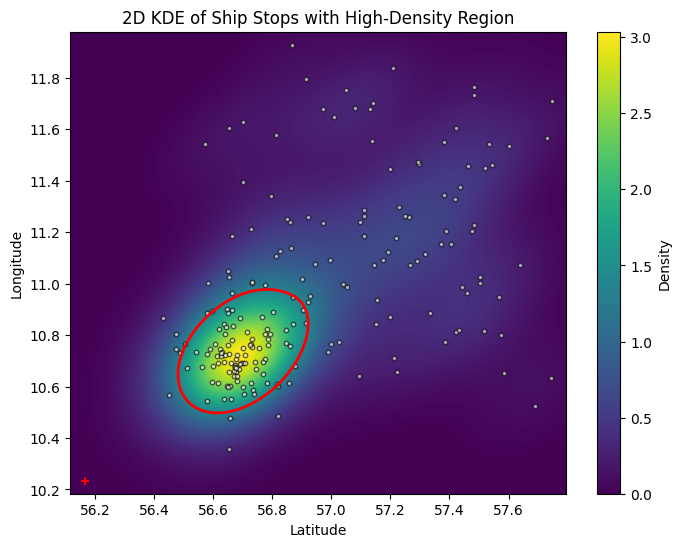

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
c = ax.imshow(
    z,
    origin='lower',
    extent=[xmin, xmax, ymin, ymax],
    cmap=cm.viridis,
    aspect='auto'
)
fig.colorbar(c, ax=ax, label='Density')

contours = ax.contour(
    x,
    y,
    z,
    levels=[level],
    colors='red',
    linewidths=2
)

ax.scatter(cx,cy, marker = "+", c='r')
ax.scatter(lat, lon, s=10, c='white', edgecolor='black', alpha=0.6)

ax.set_title('2D KDE of Ship Stops with High-Density Region')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
plt.show()

### DBSCAN

In [39]:
# tune eps (radius) and min_samples (minimum cluster size)
db = DBSCAN(eps=8, min_samples=10).fit(new_data)
labels = db.labels_

In [40]:
polygons = []

# for each cluster label (ignore noise: label == -1)
for label in set(labels):
    if label == -1:
        continue

    cluster_pts = new_data[labels == label]
    mp = MultiPoint(cluster_pts)

    # convex hull (fast, may overestimate)
    hull = mp.convex_hull
    polygons.append(hull)

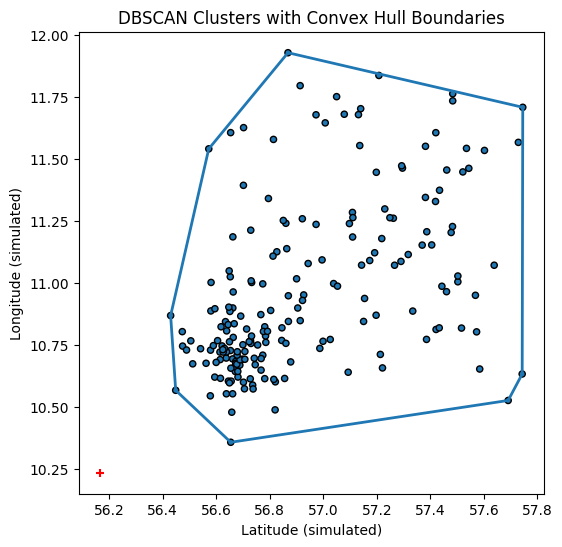

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(cx,cy, marker = "+", c='r')
# scatter colored by cluster label
scatter = ax.scatter(
    new_data[:, 0], new_data[:, 1],
    c=labels, cmap='tab10', s=20, edgecolor='k'
)

# plot each hull
for hull in polygons:
    x, y = hull.exterior.xy
    ax.plot(x, y, linewidth=2)

ax.set_title('DBSCAN Clusters with Convex Hull Boundaries')
ax.set_xlabel('Latitude (simulated)')
ax.set_ylabel('Longitude (simulated)')
plt.show()

## draw on map

In [42]:
import json
json_path = r"/home/thang_sinay/unlocode/output/shipnext_ports_test.json"

with open(json_path, 'r') as file:
    shipnext_data = json.load(file)

In [43]:
geo_json_data = shipnext_data[-1]['featureCollection']
center = shipnext_data[-1]['coordinates'][::-1]
cx, cy = center

points = []
cluster = np.random.randn(100, 2)*0.1 + np.array([cx+0.5, cy+0.5])
points.append(cluster)
points = np.vstack(points)

noise = np.random.rand(100, 2) * 1
data = np.vstack(points + [noise])

new_data = np.concatenate((points, data))

lat, lon = new_data[:,0], new_data[:,1]

In [44]:
# tune eps (radius) and min_samples (minimum cluster size)
db = DBSCAN(eps=8, min_samples=10).fit(new_data)
labels = db.labels_

polygons = []

# for each cluster label (ignore noise: label == -1)
for label in set(labels):
    if label == -1:
        continue

    cluster_pts = new_data[labels == label]
    mp = MultiPoint(cluster_pts)

    # convex hull (fast, may overestimate)
    hull = mp.convex_hull
    polygons.append(hull)

In [45]:
coords = np.vstack([lat, lon])
kde = gaussian_kde(coords)


xmin, xmax = lat.min() - 0.05, lat.max() + 0.05
ymin, ymax = lon.min() - 0.05, lon.max() + 0.05
xmin, ymin = cx-0.05,cy-0.05

nx, ny = 200, 200
xgrid = np.linspace(xmin, xmax, nx)
ygrid = np.linspace(ymin, ymax, ny)

x, y = np.meshgrid(xgrid, ygrid)
z = kde(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)

level = np.percentile(z, 95)


# Create contour lines (not filled contours)
contour = plt.contour(x, y, z, levels=[level])

# Extract paths from the first contour level
paths = contour.get_paths()

plt.close()

contours = []

for path in paths:
    v = path.vertices
    contours.append([[vtx[0], vtx[1]] for vtx in v])

In [46]:
import folium
map = folium.Map(location=center, zoom_start=12)
folium.Marker(location=center, tooltip=shipnext_data[-1]['unLoCode'], popup="central", icon=folium.Icon(color="green")).add_to(map)

folium.GeoJson(geo_json_data).add_to(map)

for x, y in new_data:
    folium.CircleMarker(
        location = [x, y],
        radius = 0.5,
        color="black"
    ).add_to(map)

for hull in polygons:
    x, y = hull.exterior.xy
    hull_coord = np.vstack((x,y)).transpose()
    folium.Polygon(
        locations=hull_coord,
        color='red',
        tooltip = "waiting zone"
    ).add_to(map)

for hull in contours:
    folium.Polygon(
        locations=hull,
        color='red',
        fill=True,
        fill_opacity=0.4,
        popup='95% KDE contour'
    ).add_to(map)
map

In [47]:
shipnext_data[-1]

{'_id': '581fb95254e6080aa866a7b7',
 'name': 'Aarhus',
 'unLoCode': 'DKAAR',
 'country': {'_id': '581c9a0937c38af7940e06ae', 'name': 'Denmark'},
 'coordinates': [10.2333, 56.1666],
 'additionalDescription': "Location: Aarhus port is situated in Aarhus Bay on the E coast of Jutland. General overview: Aarhus is the largest container port in Denmark, handling over 60% of the country's total container traffic and the harbour is open all year round. The port has direct connection to the European motorway E45 and an international airport. Principal imports are coal, grain, oil cake, fodder, copra oil, fertilisers, soya beans and timber. Main exports are agricultural products including dairy produce, vegetable oils, canned meat, bacon and condensed milk. Refrigerating plant, furniture and machinery are also exported. Traffic figures: Approx 11,287,000t of cargo, 396,000TEU, 8,136 vessels and Ro-Ro ferries, including 25 major cruise vessels handled annually. Load line zone: Summer Zone for shi